<a href="https://colab.research.google.com/github/freyebeans/ASU-assignments/blob/main/MAT422/HW2.2/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 Section 2.2 Probability and Random Variables
Michael Bishop

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2.2.1 Probability Axioms
In probability, the space of all possible values is called the sample space and is often denoted *S*. A subset of the sample space is called an event and each event *A* has a probability *P*(*A*). These probabilities should have certain properties.

In [2]:
S = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
probabilities = np.ones(20)/20
event_a = S > 10
event_b = S % 2 == 1

print("Are all probabilities in range [0,1]?", np.all((probabilities >= 0) & (probabilities <= 1)))
print("Total probability P(S) =", probabilities.sum())
print("P(A: greater than 10) =", probabilities[event_a].sum())
print("P(B: odd) =", probabilities[event_b].sum())
print("P(A \u222a B) =", probabilities[event_a | event_b].sum())
print("P(A) + P(B) - P(A \u2229 B) =", probabilities[event_a].sum() + probabilities[event_b].sum() - probabilities[event_a & event_b].sum())

Are all probabilities in range [0,1]? True
Total probability P(S) = 1.0000000000000002
P(A: greater than 10) = 0.5
P(B: odd) = 0.5
P(A ∪ B) = 0.7500000000000002
P(A) + P(B) - P(A ∩ B) = 0.75


One property which is satified by the above output is that the probability of the sample space *S*, *P*(*S*) must be 1. Another property is that for any event *A*, $1\ge P(A) \ge 0$ which is also true for the above example. Yet another property that is satified is that for two events *A* and *B*, $P(A\cup B) = P(A)+P(B)-P(A \cap B)$.
## 2.2.2 Conditional Probability
Sometimes probabilities of events can be dependent on whether another event has occured. The probability of an event *A* occuring given that an event *B* has occured is written as *P*(*A*|*B*) which is equal to $\frac{P(A\cap B)}{P(B)}$. One instance where the probability of an event occuring being dependent on another event occuring is in the ordering of a deck of cards.

In [3]:
card_values = np.arange(1,14) #1 -> A, 11 -> J, 12 -> Q, 13 -> K
card_suites = np.array([0,1,2,3]) #0 -> ♣, 1 -> ♥, 2 -> ♠, 3 -> ♦
cards = np.stack((np.tile(card_values,4),np.repeat(card_suites,13)))
card_weights = np.ones_like(cards[0])

p_ace_spades = card_weights[(cards[0] == 1) & (cards[1] == 2)].sum() / len(cards[0])
p_spades = card_weights[(cards[1] == 2)].sum() / len(cards[0])

cards_no_ace_spades = cards.T[(cards[0] != 1) | (cards[1] != 2)].T
card_weights_no_ace_spades = card_weights[(cards[0] != 1) | (cards[1] != 2)]

p_spades_given_ace_spades = (card_weights_no_ace_spades[(cards_no_ace_spades[1] == 2)].sum() / (len(cards_no_ace_spades[0])))

print("P(card 2 is \u2660) =",p_spades)
print("P(card 2 is \u2660 | card 1 is A\u2660) =",p_spades_given_ace_spades)

P(card 2 is ♠) = 0.25
P(card 2 is ♠ | card 1 is A♠) = 0.23529411764705882


As you can see above the probability of the second card in a shuffled deck being spades, is not independet of the first card being an ace of spades. Let *C* represent the deck of cards, we can see this because $P(C_2 \text{ is } ♠) \ne P(C_2 \text{ is } ♠ | C_1 \text{ is } A♠) \ \ _{(0.25\ne 0.23529...)}$.
## 2.2.3 Discrete Random Variables
A random variable is a function that maps from a probability space to the real numbers. A discrete random variable is one where the function that maps to the real numbers has a set *X* of possible values, each with specific probabilities. A probability mass function (pmf) tells us the probability that of discrete random variable is equal to a particular value. A PMF is defined as such $p(x)=P(X=x)=P(\text{all }s\in S:X(x)=x)$.

E[X] = 2.4499999999999997
Var(X) = 1.3475


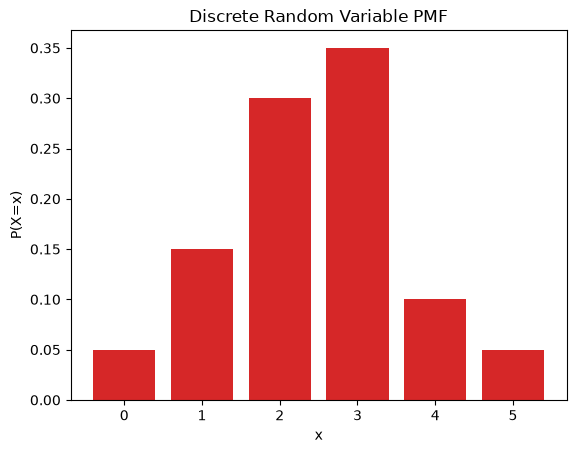

In [4]:
x = np.array([0,1,2,3,4,5])
pmf = np.array([0.05,0.15,0.3,0.35,0.1,0.05])
expected_value = np.sum(x * pmf)
variance = np.sum((x-expected_value) ** 2 * pmf)

print("E[X] =",expected_value)
print("Var(X) =",variance)

plt.bar(x, pmf, color="tab:red")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.title("Discrete Random Variable PMF")
plt.show()

As you can see in the graph above, the value 3 has the highest likelyhood of being selected according to the PMF, and the expected value is consequently close to 3. The variance of the *X* values is not particularily high because, as you can see in the graph, the possible values are relatively close together.
## 2.2.4 Continuous Random Variables
A continous random variable *X*, unlike a discrete random variable, has possible values across one or more disjoint intervals in the real number line. The probability of a particular outcome in X is defined as $P(a\le X\le b)=\int^b_af(x)dx$ where a and b are real numbers such that $a\le b$ and f(x) is a probability density function (pdf). A probability density function f(x) must be greater than or equal to 0 for all x and satisfy $\int^{\infty}_{-\infty} f(x)dx=1$.

Aprroximate total area under probability density function = 0.999936634585616
Aprroximate P(0 <= X <= 1) = 0.3347235465402315


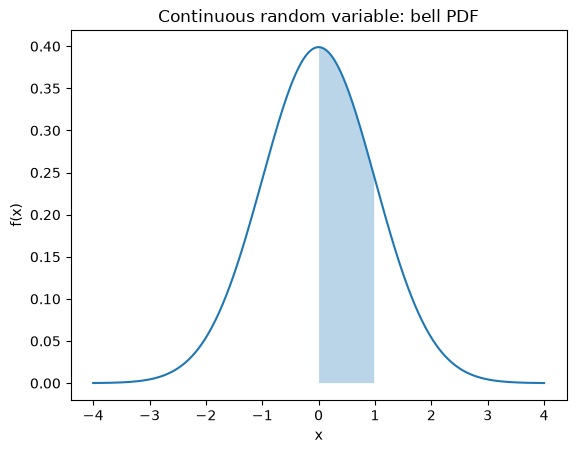

In [5]:
grid = np.linspace(-4,4,500)
scalar = 1/np.sqrt(2*np.pi)
pdf = scalar * np.exp(-0.5 * grid ** 2)

approx_area = np.trapezoid(pdf,grid)
p_1_stdv_above = np.trapezoid(pdf[(grid <= 1) & (grid >= 0)], grid[(grid <= 1) & (grid >= 0)])

print("Aprroximate total area under probability density function =", approx_area)
print("Aprroximate P(0 <= X <= 1) =", p_1_stdv_above)

plt.plot(grid, pdf, color="tab:blue")
plt.fill_between(grid[(grid <= 1) & (grid >= 0)], pdf[(grid <= 1) & (grid >= 0)], alpha=0.3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Continuous random variable: bell PDF")
plt.show()

As you can see, this bell curve is a valid PDF as its total area is probably 1 (it is 1), and all its values are above 0. Additionaly we can see that the probability of X being on the interval [0,1] is about 0.3.
## Reflection and Rubric Checklist
- I explained each concpet before and after the code.
- I verifed important claims numerically or visually.
- I changed and extended at least one example so that the notebook reflects my own work.
- I ran the notebook in its entirety without error.
- I saved the notebook from Google Colab directly to GitHub as per course instructions.